## Key Changes

* Standardized the analysis unit at the `id_student + code_module + code_presentation` level.
* Directly connected the output of Module 4 to Module 5.
* Expanded feature engineering with VLE features, assessment features, RFM features, ratio features, flag features, and time-based features.
* Added feature selection and outlier audit.
* Compared the full feature set with the compact feature set.
* Tuned K-Means, Hierarchical Clustering, and DBSCAN more thoroughly.
* Added stability validation.
* Added final-result profiling, persona mapping, recommendations, and artifact saving for deployment.


# Module 4: Feature Engineering

In [1]:
import io
import os
import re
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
KEY_COLS = ["id_student", "code_module", "code_presentation"]
OUTPUT_DIR = Path("artifacts")
REPORT_DIR = Path("reports")
FIGURE_DIR = Path("figures")

for path in [OUTPUT_DIR, REPORT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DRIVE_FILE_URL = "https://drive.google.com/file/d/1eFIYrXSrVlUaA7Pvzu1nP0H-v01NFNQe/view?usp=sharing"
LOCAL_CANDIDATES = [
    "merged_student_behavior.csv",
    "merged_student_behavior.xlsx",
    "shared_data.csv",
    "shared_data.xlsx",
    "data/processed/merged_student_behavior.csv",
    "data/processed/merged_student_behavior.xlsx",
]

VARIANCE_THRESHOLD = 0.01
CORRELATION_THRESHOLD = 0.95
REMOVE_OUTLIERS_FOR_MODEL = True
OUTLIER_CONTAMINATION = 0.05
K_RANGE = range(2, 11)

In [2]:
def read_shared_data():
    for path in LOCAL_CANDIDATES:
        if Path(path).exists():
            if path.lower().endswith(".csv"):
                return pd.read_csv(path)
            return pd.read_excel(path)

    import requests

    match = re.search(r"/d/([^/]+)", DRIVE_FILE_URL)
    if not match:
        raise ValueError("Invalid Google Drive URL.")

    file_id = match.group(1)
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    response = requests.get(url, timeout=60)
    response.raise_for_status()

    content = response.content
    try:
        return pd.read_csv(io.BytesIO(content))
    except Exception:
        return pd.read_excel(io.BytesIO(content))


shared_df = read_shared_data()

print("Shared data loaded.")
print("Shape:", shared_df.shape)
print("Unique students:", shared_df["id_student"].nunique() if "id_student" in shared_df.columns else "N/A")
display(shared_df.head())

Shared data loaded.
Shape: (32593, 48)
Unique students: 28785


,id_student,code_module,code_presentation,final_result,login_weekly,dominant_login_time,video_completion_rate,days_to_first_activity,forum_posts_count,submission_timeliness_days,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,date_unregistration,vle_total_clicks,vle_active_days,vle_distinct_sites,vle_clicks_dataplus,vle_clicks_dualpane,vle_clicks_externalquiz,vle_clicks_folder,vle_clicks_forumng,vle_clicks_glossary,vle_clicks_homepage,vle_clicks_htmlactivity,vle_clicks_oucollaborate,vle_clicks_oucontent,vle_clicks_ouelluminate,vle_clicks_ouwiki,vle_clicks_page,vle_clicks_questionnaire,vle_clicks_quiz,vle_clicks_repeatactivity,vle_clicks_resource,vle_clicks_sharedsubpage,vle_clicks_subpage,vle_clicks_url,assess_n_submitted,assess_mean_score,assess_n_banked,assess_mean_days_before_deadline,assess_n_late
0,11391,AAA,2013J,Pass,2,Afternoon,0.934,9.0,5,-0.2,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,-159.0,NaN,934.0,40.0,55.0,0.0,0.0,0.0,0.0,193.0,0.0,138.0,0.0,0.0,553.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,32.0,5.0,5.0,82.0,0.0,1.8,0.0
1,28400,AAA,2013J,Pass,6,Evening,0.879,2.0,0,-1.5,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,-53.0,NaN,1435.0,80.0,84.0,10.0,0.0,0.0,0.0,417.0,0.0,324.0,0.0,0.0,537.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,87.0,48.0,5.0,66.4,0.0,0.0,2.0
2,30268,AAA,2013J,Withdrawn,0,Evening,0.522,NaN,0,3.4,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,-92.0,12.0,281.0,12.0,22.0,0.0,0.0,0.0,0.0,126.0,0.0,59.0,0.0,0.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,22.0,4.0,NaN,NaN,NaN,NaN,NaN
3,31604,AAA,2013J,Pass,8,Evening,0.521,3.0,2,2.2,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,-52.0,NaN,2158.0,123.0,82.0,2.0,0.0,0.0,0.0,634.0,1.0,432.0,0.0,0.0,836.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,144.0,90.0,5.0,76.0,0.0,2.0,0.0
4,32885,AAA,2013J,Pass,0,Afternoon,0.240,7.0,2,-0.4,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,-176.0,NaN,1034.0,70.0,66.0,0.0,0.0,0.0,0.0,194.0,4.0,204.0,0.0,0.0,494.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,0.0,79.0,14.0,5.0,54.4,0.0,-11.4,5.0


In [3]:
required_base_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "final_result",
    "login_weekly",
    "dominant_login_time",
    "video_completion_rate",
    "days_to_first_activity",
    "forum_posts_count",
    "submission_timeliness_days",
]

missing_required = [c for c in required_base_cols if c not in shared_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

raw_df = shared_df.copy()
before_rows = len(raw_df)
df = raw_df.drop_duplicates(subset=KEY_COLS).reset_index(drop=True)
after_rows = len(df)

missing_report = (
    df.isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("missing_pct", ascending=False)
)

print("Rows before de-duplication:", before_rows)
print("Rows after de-duplication by learner-course-presentation:", after_rows)
print("Duplicate rows removed:", before_rows - after_rows)
print("Observation unit:", " + ".join(KEY_COLS))
display(missing_report.head(15))
display(df.describe(include="all").T)

Rows before de-duplication: 32593
Rows after de-duplication by learner-course-presentation: 32593
Duplicate rows removed: 0
Observation unit: id_student + code_module + code_presentation


,column,missing_pct
19,date_unregistration,69.10
44,assess_mean_score,20.78
43,assess_n_submitted,20.71
46,assess_mean_days_before_deadline,20.71
47,assess_n_late,20.71
45,assess_n_banked,20.71
7,days_to_first_activity,13.91
25,vle_clicks_externalquiz,10.32
22,vle_distinct_sites,10.32
21,vle_active_days,10.32


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_student,32593.0,NaN,NaN,NaN,706687.669131,549167.313855,3733.0,508573.0,590310.0,644453.0,2716795.0
code_module,32593,7,BBB,7909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_presentation,32593,4,2014J,11260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final_result,32593,4,Pass,12361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
login_weekly,32593.0,NaN,NaN,NaN,2.616635,3.479342,0.0,0.0,1.0,4.0,24.0
dominant_login_time,32593,4,Afternoon,11390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
video_completion_rate,32593.0,NaN,NaN,NaN,0.444531,0.359951,0.0,0.082,0.388,0.808,1.0
days_to_first_activity,28058.0,NaN,NaN,NaN,10.498396,12.466346,0.0,2.0,6.0,14.0,90.0
forum_posts_count,32593.0,NaN,NaN,NaN,1.449514,2.506308,0.0,0.0,0.0,2.0,19.0
submission_timeliness_days,32593.0,NaN,NaN,NaN,0.362056,3.172153,-11.6,-1.8,0.4,2.6,12.2


In [4]:
def safe_divide(a, b):
    return a / b.replace(0, np.nan)


def safe_zscore(series):
    series = pd.Series(series)
    std = series.std()
    if std == 0 or pd.isna(std):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std


def first_existing(columns, candidates):
    return [c for c in candidates if c in columns]


def build_feature_table(data):
    work = data.copy()

    numeric_fill_zero = [
        c for c in work.columns
        if c.startswith("vle_") or c.startswith("assess_")
    ]
    for col in numeric_fill_zero:
        if pd.api.types.is_numeric_dtype(work[col]):
            work[col] = work[col].fillna(0)

    work["never_started"] = work["days_to_first_activity"].isna().astype(int)
    fallback_first_day = work["days_to_first_activity"].max()
    if pd.isna(fallback_first_day):
        fallback_first_day = 90
    work["days_to_first_filled"] = work["days_to_first_activity"].fillna(fallback_first_day)

    work["missed_submission"] = (
        (work["submission_timeliness_days"] > 7) |
        (work.get("assess_n_submitted", pd.Series(0, index=work.index)).fillna(0) == 0)
    ).astype(int)

    work["late_submitter"] = (work["submission_timeliness_days"] > 7).astype(int)
    work["prompt_starter"] = (
        work["days_to_first_filled"] <= work["days_to_first_filled"].median()
    ).astype(int)

    work["early_start_score"] = 1 / (1 + work["days_to_first_filled"])
    work["frequency_score"] = safe_zscore(work["login_weekly"]) + safe_zscore(work["forum_posts_count"])
    work["intensity_score"] = (
        safe_zscore(work["video_completion_rate"]) +
        safe_zscore(-work["submission_timeliness_days"])
    )
    work["forum_per_login"] = work["forum_posts_count"] / (work["login_weekly"] + 1)
    work["completion_x_frequency"] = work["video_completion_rate"] * work["login_weekly"]
    work["procrastination_score"] = (
        safe_zscore(work["days_to_first_filled"]) +
        safe_zscore(work["submission_timeliness_days"])
    )

    work["low_engagement_flag"] = (
        (work["login_weekly"] <= work["login_weekly"].quantile(0.25)) &
        (work["video_completion_rate"] <= work["video_completion_rate"].quantile(0.25))
    ).astype(int)

    work["engagement_breadth"] = (
        (work["login_weekly"] > work["login_weekly"].median()).astype(int) +
        (work["video_completion_rate"] > work["video_completion_rate"].median()).astype(int) +
        (work["forum_posts_count"] > work["forum_posts_count"].median()).astype(int) +
        (work["submission_timeliness_days"] < work["submission_timeliness_days"].median()).astype(int)
    )

    if "date_registration" in work.columns:
        work["registration_delay_days"] = work["date_registration"].fillna(work["date_registration"].median())
        work["registered_before_start"] = (work["registration_delay_days"] < 0).astype(int)
    else:
        work["registration_delay_days"] = 0
        work["registered_before_start"] = 0

    if "date_unregistration" in work.columns:
        work["is_unregistered"] = work["date_unregistration"].notna().astype(int)
    else:
        work["is_unregistered"] = 0

    if "vle_total_clicks" in work.columns:
        work["log_vle_total_clicks"] = np.log1p(work["vle_total_clicks"])
    if "vle_active_days" in work.columns:
        work["log_vle_active_days"] = np.log1p(work["vle_active_days"])
    if "vle_distinct_sites" in work.columns:
        work["log_vle_distinct_sites"] = np.log1p(work["vle_distinct_sites"])

    if {"vle_total_clicks", "vle_active_days"}.issubset(work.columns):
        work["clicks_per_active_day"] = safe_divide(work["vle_total_clicks"], work["vle_active_days"]).fillna(0)
        work["log_clicks_per_active_day"] = np.log1p(work["clicks_per_active_day"])

    vle_click_cols = [c for c in work.columns if c.startswith("vle_clicks_")]
    if vle_click_cols:
        total = work[vle_click_cols].sum(axis=1).replace(0, np.nan)
        for col in vle_click_cols:
            work[f"{col}_ratio"] = (work[col] / total).fillna(0)
        work["vle_activity_type_diversity"] = work[vle_click_cols].gt(0).sum(axis=1)

    if "assess_n_submitted" in work.columns:
        total_possible = (
            work.groupby(["code_module", "code_presentation"])["assess_n_submitted"]
            .transform("max")
            .replace(0, np.nan)
        )
        work["assessment_completion_rate"] = (work["assess_n_submitted"] / total_possible).fillna(0)
    else:
        work["assessment_completion_rate"] = 0

    if {"assess_n_late", "assess_n_submitted"}.issubset(work.columns):
        work["late_assessment_rate"] = safe_divide(work["assess_n_late"], work["assess_n_submitted"]).fillna(0)
    else:
        work["late_assessment_rate"] = work["late_submitter"]

    if "assess_mean_days_before_deadline" in work.columns:
        work["assignment_timeliness_score"] = safe_zscore(work["assess_mean_days_before_deadline"])
    else:
        work["assignment_timeliness_score"] = safe_zscore(-work["submission_timeliness_days"])

    login_dummies = pd.get_dummies(work["dominant_login_time"], prefix="login_time").astype(int)
    work = pd.concat([work, login_dummies], axis=1)

    return work


feature_df = build_feature_table(df)

display(feature_df.head())
print("Feature table shape:", feature_df.shape)

,id_student,code_module,code_presentation,final_result,login_weekly,dominant_login_time,video_completion_rate,days_to_first_activity,forum_posts_count,submission_timeliness_days,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,date_unregistration,vle_total_clicks,vle_active_days,vle_distinct_sites,vle_clicks_dataplus,vle_clicks_dualpane,vle_clicks_externalquiz,vle_clicks_folder,vle_clicks_forumng,vle_clicks_glossary,vle_clicks_homepage,vle_clicks_htmlactivity,vle_clicks_oucollaborate,vle_clicks_oucontent,vle_clicks_ouelluminate,vle_clicks_ouwiki,vle_clicks_page,vle_clicks_questionnaire,vle_clicks_quiz,vle_clicks_repeatactivity,vle_clicks_resource,vle_clicks_sharedsubpage,vle_clicks_subpage,vle_clicks_url,assess_n_submitted,assess_mean_score,assess_n_banked,assess_mean_days_before_deadline,assess_n_late,never_started,days_to_first_filled,missed_submission,late_submitter,prompt_starter,early_start_score,frequency_score,intensity_score,forum_per_login,completion_x_frequency,procrastination_score,low_engagement_flag,engagement_breadth,registration_delay_days,registered_before_start,is_unregistered,log_vle_total_clicks,log_vle_active_days,log_vle_distinct_sites,clicks_per_active_day,log_clicks_per_active_day,vle_clicks_dataplus_ratio,vle_clicks_dualpane_ratio,vle_clicks_externalquiz_ratio,vle_clicks_folder_ratio,vle_clicks_forumng_ratio,vle_clicks_glossary_ratio,vle_clicks_homepage_ratio,vle_clicks_htmlactivity_ratio,vle_clicks_oucollaborate_ratio,vle_clicks_oucontent_ratio,vle_clicks_ouelluminate_ratio,vle_clicks_ouwiki_ratio,vle_clicks_page_ratio,vle_clicks_questionnaire_ratio,vle_clicks_quiz_ratio,vle_clicks_repeatactivity_ratio,vle_clicks_resource_ratio,vle_clicks_sharedsubpage_ratio,vle_clicks_subpage_ratio,vle_clicks_url_ratio,vle_activity_type_diversity,assessment_completion_rate,late_assessment_rate,assignment_timeliness_score,login_time_Afternoon,login_time_Evening,login_time_Morning,login_time_Night
0,11391,AAA,2013J,Pass,2,Afternoon,0.934,9.0,5,-0.2,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,-159.0,NaN,934.0,40.0,55.0,0.0,0.0,0.0,0.0,193.0,0.0,138.0,0.0,0.0,553.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,32.0,5.0,5.0,82.0,0.0,1.8,0.0,0,9.0,0,0,0,0.100000,1.239393,1.537005,1.666667,1.868,-0.597998,0,4,-159.0,1,0,6.840547,3.713572,4.025352,23.350000,3.192532,0.000000,0.0,0.0,0.0,0.206638,0.000000,0.147752,0.0,0.0,0.592077,0.0,0.0,0.0,0.0,0.0,0.0,0.013919,0.0,0.034261,0.005353,6,1.0,0.0,-0.319689,1,0,0,0
1,28400,AAA,2013J,Pass,6,Evening,0.879,2.0,0,-1.5,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,-53.0,NaN,1435.0,80.0,84.0,10.0,0.0,0.0,0.0,417.0,0.0,324.0,0.0,0.0,537.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,87.0,48.0,5.0,66.4,0.0,0.0,2.0,0,2.0,0,0,1,0.333333,0.394069,1.794023,0.000000,5.274,-1.242339,0,3,-53.0,1,0,7.269617,4.394449,4.442651,17.937500,2.941144,0.006969,0.0,0.0,0.0,0.290592,0.000000,0.225784,0.0,0.0,0.374216,0.0,0.0,0.0,0.0,0.0,0.0,0.008362,0.0,0.060627,0.033449,7,1.0,0.4,-0.394787,0,1,0,0
2,30268,AAA,2013J,Withdrawn,0,Evening,0.522,NaN,0,3.4,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,-92.0,12.0,281.0,12.0,22.0,0.0,0.0,0.0,0.0,126.0,0.0,59.0,0.0,0.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,1,90.0,1,0,0,0.010989,-1.330395,-0.742471,0.000000,0.000,3.250662,0,1,-92.0,1,1,5.641907,2.564949,3.135494,23.416667,3.195266,0.000000,0.0,0.0,0.0,0.448399,0.000000,0.209964,0.0,0.0,0.234875,0.0,0.0,0.0,0.0,0.0,0.0,0.014235,0.0,0.078292,0.014235,6,0.0,0.0,-0.394787,0,1,0,0
3,31604,AAA,2013J,Pass,8,Evening,0.521,3.0,2,2.2,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,-52.0,NaN,2158.0,123.0,82.0,2.0,0.0,0.0,0.0,634.0,1.0,432.0,0.0,0.0,836.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,144.0,90.0,5.0,76.0,0.0,2.0,0.0,0,3.0,0,0,1,0.250000,1.766877,-0.366957,0.222222,4.168,-0.042435,0,3,-52.0,1,0,7.677400,4.820282,4.418841,17.544715,2.920185,0.000927,0.0,0.0,0.0,0.293791,0.000463,0.200185,0.0,0.0,0.387396,0

Feature table shape: (32593, 97)


In [5]:
base_behavior_features = [
    "login_weekly",
    "video_completion_rate",
    "forum_posts_count",
    "days_to_first_filled",
    "submission_timeliness_days",
    "never_started",
    "missed_submission",
    "late_submitter",
    "prompt_starter",
    "low_engagement_flag",
    "early_start_score",
    "frequency_score",
    "intensity_score",
    "forum_per_login",
    "completion_x_frequency",
    "procrastination_score",
    "engagement_breadth",
    "registration_delay_days",
    "registered_before_start",
]

vle_features = first_existing(feature_df.columns, [
    "vle_total_clicks",
    "vle_active_days",
    "vle_distinct_sites",
    "log_vle_total_clicks",
    "log_vle_active_days",
    "log_vle_distinct_sites",
    "clicks_per_active_day",
    "log_clicks_per_active_day",
    "vle_activity_type_diversity",
])

vle_ratio_features = [
    c for c in feature_df.columns
    if c.startswith("vle_clicks_") and c.endswith("_ratio")
]

preferred_vle_ratios = first_existing(feature_df.columns, [
    "vle_clicks_forumng_ratio",
    "vle_clicks_resource_ratio",
    "vle_clicks_oucontent_ratio",
    "vle_clicks_quiz_ratio",
    "vle_clicks_homepage_ratio",
    "vle_clicks_subpage_ratio",
    "vle_clicks_url_ratio",
])

assessment_features = first_existing(feature_df.columns, [
    "assess_n_submitted",
    "assess_mean_score",
    "assess_n_banked",
    "assess_mean_days_before_deadline",
    "assess_n_late",
    "assessment_completion_rate",
    "late_assessment_rate",
    "assignment_timeliness_score",
])

login_time_features = [c for c in feature_df.columns if c.startswith("login_time_")]

candidate_features = []
for group in [
    base_behavior_features,
    vle_features,
    preferred_vle_ratios,
    assessment_features,
    login_time_features,
]:
    for col in group:
        if col in feature_df.columns and col not in candidate_features:
            candidate_features.append(col)

feature_df[candidate_features] = feature_df[candidate_features].replace([np.inf, -np.inf], np.nan)
for col in candidate_features:
    feature_df[col] = feature_df[col].fillna(feature_df[col].median() if pd.api.types.is_numeric_dtype(feature_df[col]) else 0)

raw_candidate_path = OUTPUT_DIR / "engineered_features_raw.csv"
feature_df[KEY_COLS + candidate_features + ["final_result"]].to_csv(raw_candidate_path, index=False)

feature_overview = pd.DataFrame({
    "feature": candidate_features,
    "mean": feature_df[candidate_features].mean().round(4).values,
    "std": feature_df[candidate_features].std().round(4).values,
    "missing_pct": feature_df[candidate_features].isna().mean().mul(100).round(2).values,
    "n_unique": feature_df[candidate_features].nunique().values,
})
display(feature_overview)
print("Candidate features:", len(candidate_features))
print("Saved:", raw_candidate_path)

,feature,mean,std,missing_pct,n_unique
0,login_weekly,2.6166,3.4793,0.0,25
1,video_completion_rate,0.4445,0.3600,0.0,1001
2,forum_posts_count,1.4495,2.5063,0.0,18
3,days_to_first_filled,21.5603,29.8476,0.0,91
4,submission_timeliness_days,0.3621,3.1722,0.0,222
5,never_started,0.1391,0.3461,0.0,2
6,missed_submission,0.2160,0.4115,0.0,2
7,late_submitter,0.0167,0.1280,0.0,2
8,prompt_starter,0.5135,0.4998,0.0,2
9,low_engagement_flag,0.2178,0.4128,0.0,2


Candidate features: 47
Saved: artifacts/engineered_features_raw.csv


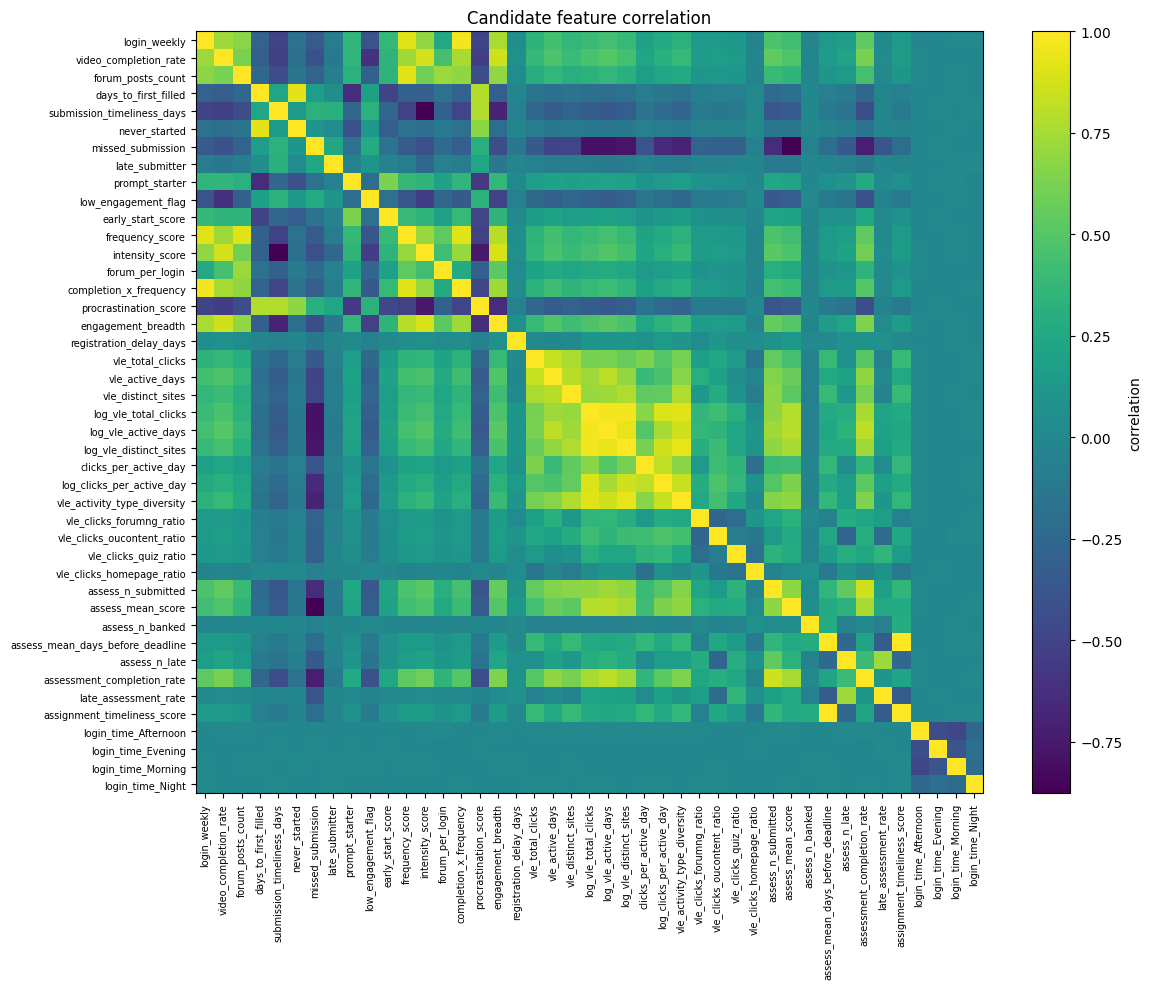

Dropped low variance: ['registered_before_start', 'vle_clicks_resource_ratio', 'vle_clicks_subpage_ratio', 'vle_clicks_url_ratio']
Dropped high correlation: ['completion_x_frequency', 'log_vle_active_days', 'log_vle_distinct_sites', 'assignment_timeliness_score']
Selected features: 39


,feature,selected,dropped_low_variance,dropped_high_corr
0,login_weekly,True,False,False
1,video_completion_rate,True,False,False
2,forum_posts_count,True,False,False
3,days_to_first_filled,True,False,False
4,submission_timeliness_days,True,False,False
5,never_started,True,False,False
6,missed_submission,True,False,False
7,late_submitter,True,False,False
8,prompt_starter,True,False,False
9,low_engagement_flag,True,False,False


In [6]:
variance_selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
variance_selector.fit(feature_df[candidate_features])

kept_by_variance = [
    c for c, keep in zip(candidate_features, variance_selector.get_support())
    if keep
]
dropped_low_variance = [c for c in candidate_features if c not in kept_by_variance]

corr_matrix = feature_df[kept_by_variance].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
dropped_high_corr = [c for c in upper.columns if any(upper[c] > CORRELATION_THRESHOLD)]

selected_features = [
    c for c in kept_by_variance
    if c not in dropped_high_corr
]

selection_report = pd.DataFrame({
    "feature": candidate_features,
    "selected": [c in selected_features for c in candidate_features],
    "dropped_low_variance": [c in dropped_low_variance for c in candidate_features],
    "dropped_high_corr": [c in dropped_high_corr for c in candidate_features],
})
selection_report.to_csv(REPORT_DIR / "feature_selection_report.csv", index=False)

plt.figure(figsize=(12, 10))
plt.imshow(feature_df[kept_by_variance].corr(), aspect="auto")
plt.colorbar(label="correlation")
plt.xticks(range(len(kept_by_variance)), kept_by_variance, rotation=90, fontsize=7)
plt.yticks(range(len(kept_by_variance)), kept_by_variance, fontsize=7)
plt.title("Candidate feature correlation")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "candidate_feature_correlation.png", dpi=150)
plt.show()

print("Dropped low variance:", dropped_low_variance or "none")
print("Dropped high correlation:", dropped_high_corr or "none")
print("Selected features:", len(selected_features))
display(selection_report)

In [7]:
model_source = feature_df[KEY_COLS + selected_features + ["final_result"]].copy()

outlier_scaler = StandardScaler()
outlier_X = outlier_scaler.fit_transform(model_source[selected_features])

outlier_model = IsolationForest(
    contamination=OUTLIER_CONTAMINATION,
    random_state=RANDOM_STATE,
)
model_source["outlier_flag"] = (outlier_model.fit_predict(outlier_X) == -1).astype(int)

outlier_audit = pd.crosstab(
    model_source["final_result"],
    model_source["outlier_flag"],
    normalize="index",
).round(3)

if REMOVE_OUTLIERS_FOR_MODEL:
    model_df = model_source[model_source["outlier_flag"] == 0].drop(columns="outlier_flag").reset_index(drop=True)
else:
    model_df = model_source.drop(columns="outlier_flag").reset_index(drop=True)

clustering_features_path = OUTPUT_DIR / "clustering_features.csv"
metadata_path = OUTPUT_DIR / "student_metadata.csv"

model_df[KEY_COLS + selected_features].to_csv(clustering_features_path, index=False)
model_df[KEY_COLS + ["final_result"]].to_csv(metadata_path, index=False)
outlier_audit.to_csv(REPORT_DIR / "outlier_audit_by_final_result.csv")

print("Rows before outlier handling:", len(model_source))
print("Rows for modeling:", len(model_df))
print("Outliers flagged:", int(model_source["outlier_flag"].sum()))
display(outlier_audit)
print("Saved:", clustering_features_path)
print("Saved:", metadata_path)

Rows before outlier handling: 32593
Rows for modeling: 30963
Outliers flagged: 1630


outlier_flag,0,1
final_result,,
Distinction,0.893,0.107
Fail,0.945,0.055
Pass,0.953,0.047
Withdrawn,0.967,0.033


Saved: artifacts/clustering_features.csv
Saved: artifacts/student_metadata.csv


In [8]:
compact_features = [
    "login_weekly",
    "video_completion_rate",
    "forum_posts_count",
    "days_to_first_filled",
    "submission_timeliness_days",
    "never_started",
    "missed_submission",
]

compact_features = [c for c in compact_features if c in model_df.columns]

feature_sets = {
    "compact_behavior": compact_features,
    "engineered_selected": selected_features,
}

for name, cols in feature_sets.items():
    print(name, len(cols), cols)

profile_only_cols = [
    c for c in [
        "final_result",
        "dominant_login_time",
        "gender",
        "region",
        "highest_education",
        "imd_band",
        "age_band",
        "num_of_prev_attempts",
        "studied_credits",
        "disability",
        "date_unregistration",
        "vle_total_clicks",
        "vle_active_days",
        "vle_distinct_sites",
        "assess_n_submitted",
        "assess_mean_score",
        "assess_mean_days_before_deadline",
        "assess_n_late",
    ]
    if c in feature_df.columns
]

profile_df = model_df[KEY_COLS + ["final_result"]].merge(
    feature_df[KEY_COLS + profile_only_cols],
    on=KEY_COLS,
    how="left",
    suffixes=("", "_profile"),
)

if "final_result_profile" in profile_df.columns:
    profile_df["final_result"] = profile_df["final_result"].fillna(profile_df["final_result_profile"])
    profile_df = profile_df.drop(columns=["final_result_profile"])

display(profile_df.head())

compact_behavior 7 ['login_weekly', 'video_completion_rate', 'forum_posts_count', 'days_to_first_filled', 'submission_timeliness_days', 'never_started', 'missed_submission']
engineered_selected 39 ['login_weekly', 'video_completion_rate', 'forum_posts_count', 'days_to_first_filled', 'submission_timeliness_days', 'never_started', 'missed_submission', 'late_submitter', 'prompt_starter', 'low_engagement_flag', 'early_start_score', 'frequency_score', 'intensity_score', 'forum_per_login', 'procrastination_score', 'engagement_breadth', 'registration_delay_days', 'vle_total_clicks', 'vle_active_days', 'vle_distinct_sites', 'log_vle_total_clicks', 'clicks_per_active_day', 'log_clicks_per_active_day', 'vle_activity_type_diversity', 'vle_clicks_forumng_ratio', 'vle_clicks_oucontent_ratio', 'vle_clicks_quiz_ratio', 'vle_clicks_homepage_ratio', 'assess_n_submitted', 'assess_mean_score', 'assess_n_banked', 'assess_mean_days_before_deadline', 'assess_n_late', 'assessment_completion_rate', 'late_asse

,id_student,code_module,code_presentation,final_result,dominant_login_time,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_unregistration,vle_total_clicks,vle_active_days,vle_distinct_sites,assess_n_submitted,assess_mean_score,assess_mean_days_before_deadline,assess_n_late
0,11391,AAA,2013J,Pass,Afternoon,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,NaN,934.0,40.0,55.0,5.0,82.0,1.8,0.0
1,28400,AAA,2013J,Pass,Evening,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,NaN,1435.0,80.0,84.0,5.0,66.4,0.0,2.0
2,30268,AAA,2013J,Withdrawn,Evening,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,12.0,281.0,12.0,22.0,0.0,0.0,0.0,0.0
3,31604,AAA,2013J,Pass,Evening,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,NaN,2158.0,123.0,82.0,5.0,76.0,2.0,0.0
4,32885,AAA,2013J,Pass,Afternoon,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,NaN,1034.0,70.0,66.0,5.0,54.4,-11.4,5.0


# Module 5: Model Development

In [9]:
def evaluate_kmeans_for_features(data, features, k_range=K_RANGE):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data[features])

    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels = model.fit_predict(X_scaled)
        rows.append({
            "feature_set": None,
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        })

    return pd.DataFrame(rows), scaler, X_scaled


feature_set_results = []
scaled_cache = {}

for name, cols in feature_sets.items():
    result, scaler, X_scaled = evaluate_kmeans_for_features(model_df, cols)
    result["feature_set"] = name
    feature_set_results.append(result)
    scaled_cache[name] = {"scaler": scaler, "X_scaled": X_scaled}

feature_set_results = pd.concat(feature_set_results, ignore_index=True)
feature_set_summary = (
    feature_set_results
    .sort_values(["silhouette", "calinski_harabasz"], ascending=[False, False])
    .reset_index(drop=True)
)

display(feature_set_summary)

final_feature_set_name = "engineered_selected"
FEATURES = feature_sets[final_feature_set_name]
scaler = scaled_cache[final_feature_set_name]["scaler"]
X_scaled = scaled_cache[final_feature_set_name]["X_scaled"]
X = model_df[FEATURES].copy()

print("Final feature set:", final_feature_set_name)
print("Number of features:", len(FEATURES))

,feature_set,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,compact_behavior,4,71223.178050,0.396814,0.902673,21084.394978
1,compact_behavior,3,94073.687667,0.392228,0.985788,20185.140662
2,compact_behavior,6,53269.036388,0.369130,0.996746,19000.163477
3,compact_behavior,5,58788.749865,0.368511,0.998444,20794.336486
4,compact_behavior,2,143840.555422,0.316377,1.241101,15691.488264
5,compact_behavior,7,48983.771887,0.312568,1.069592,17669.505278
6,compact_behavior,8,45331.186323,0.308831,1.147410,16721.460836
7,compact_behavior,9,42095.519713,0.307536,1.129958,16052.828419
8,compact_behavior,10,39115.974834,0.287162,1.172172,15617.513015
9,engineered_selected,2,943020.815216,0.196157,1.833090,8685.180004


Final feature set: engineered_selected
Number of features: 39


Variance explained by 2 PCs: [0.303 0.097] | cumulative: 0.4


,PC1,PC2
assessment_completion_rate,0.247176,0.064560
log_vle_total_clicks,0.243097,0.241840
engagement_breadth,0.237701,-0.193362
assess_n_submitted,0.232427,0.095448
intensity_score,0.230694,-0.201621
assess_mean_score,0.226010,0.152797
video_completion_rate,0.225994,-0.171489
vle_activity_type_diversity,0.219816,0.263225
vle_active_days,0.215535,0.118603
frequency_score,0.214051,-0.220410


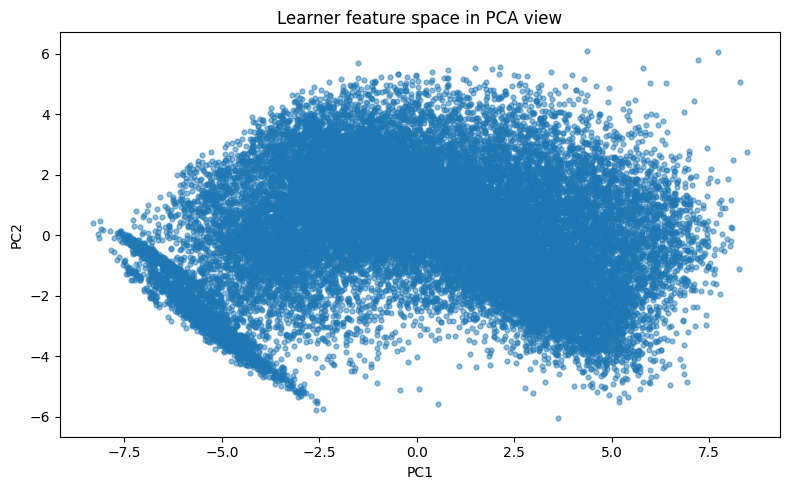

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(
    "Variance explained by 2 PCs:",
    np.round(pca.explained_variance_ratio_, 3),
    "| cumulative:",
    round(float(pca.explained_variance_ratio_.sum()), 3),
)

pca_loadings = pd.DataFrame(
    pca.components_,
    columns=FEATURES,
    index=["PC1", "PC2"],
).T.sort_values("PC1", key=lambda s: s.abs(), ascending=False)

display(pca_loadings.head(15))

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=12, alpha=0.5)
plt.title("Learner feature space in PCA view")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_feature_space.png", dpi=150)
plt.show()

,model,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_pct
0,K-Means,2,943020.8152,0.1962,1.8331,8685.1800,48.4255
1,K-Means,3,840838.2713,0.1590,2.0097,6751.3679,21.0025
2,K-Means,4,798723.1760,0.1390,2.1718,5282.2193,12.7378
3,K-Means,5,757843.6146,0.1398,2.1218,4592.7129,9.4015
4,K-Means,6,726446.4381,0.1386,2.1649,4100.4381,9.3531
5,K-Means,7,698741.7946,0.1249,2.0462,3756.9647,1.0238
6,K-Means,8,670280.5974,0.1253,2.0797,3544.6546,1.0238
7,K-Means,9,649518.6922,0.1236,2.0617,3324.2942,1.0238
8,K-Means,10,624107.0672,0.1270,1.9259,3215.1781,0.8139


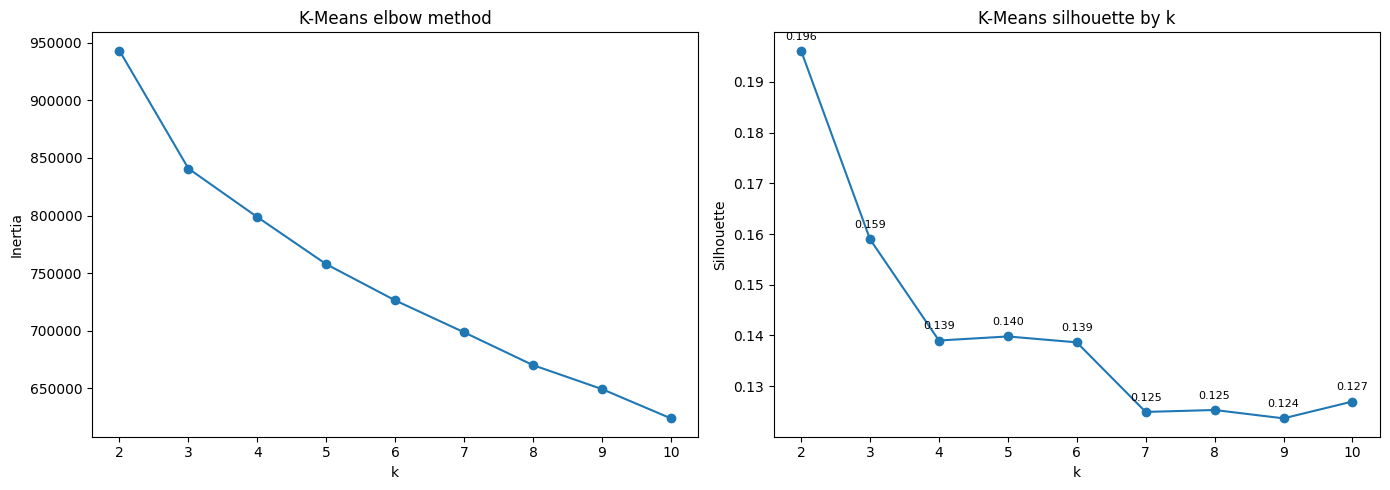

Chosen K: 3


In [11]:
kmeans_results = []

for k in K_RANGE:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    labels = model.fit_predict(X_scaled)
    kmeans_results.append({
        "model": "K-Means",
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "min_cluster_pct": pd.Series(labels).value_counts(normalize=True).min() * 100,
    })

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(kmeans_results["k"], kmeans_results["inertia"], "o-")
ax[0].set_title("K-Means elbow method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(kmeans_results["k"], kmeans_results["silhouette"], "o-")
ax[1].set_title("K-Means silhouette by k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
for _, row in kmeans_results.iterrows():
    ax[1].annotate(
        f"{row['silhouette']:.3f}",
        (row["k"], row["silhouette"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_elbow_silhouette.png", dpi=150)
plt.show()

K = int(kmeans_results.loc[kmeans_results["silhouette"].idxmax(), "k"])
if K < 3:
    K = int(
        kmeans_results
        .query("k >= 3")
        .sort_values("silhouette", ascending=False)
        .iloc[0]["k"]
    )

print("Chosen K:", K)

K-Means silhouette = 0.1590
Cluster sizes: {0: 12273, 1: 12187, 2: 6503}


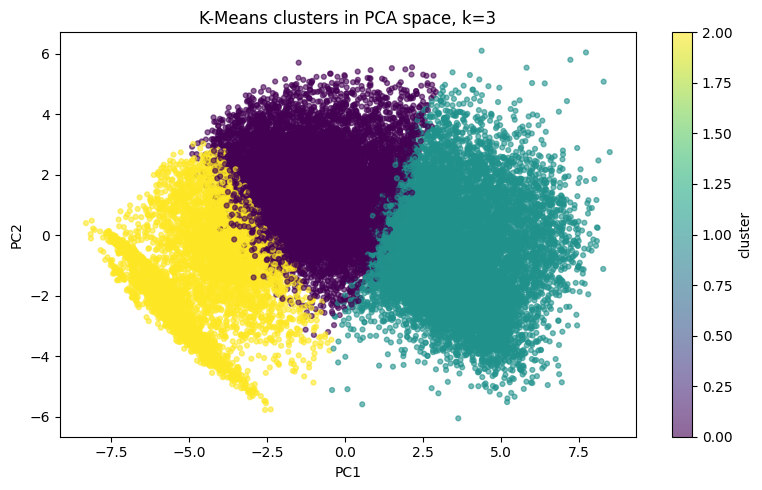

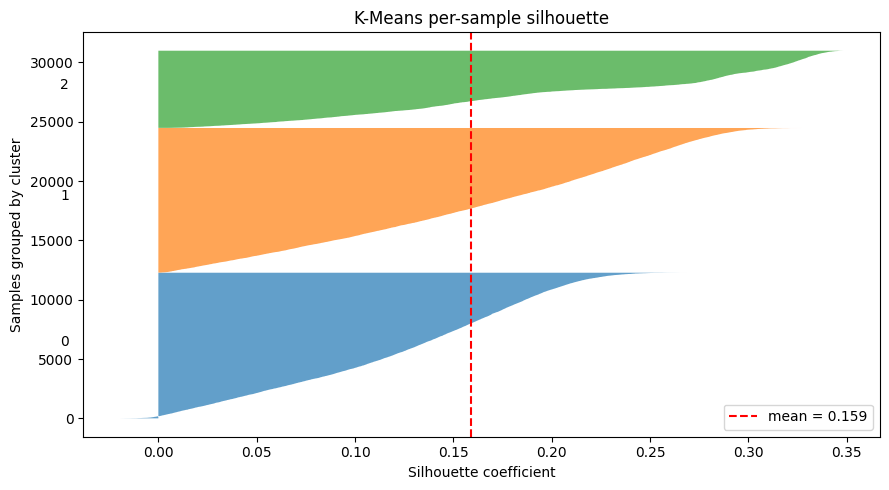

In [12]:
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=50)
km_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)

print(f"K-Means silhouette = {km_sil:.4f}")
print("Cluster sizes:", pd.Series(km_labels).value_counts().sort_index().to_dict())

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, s=12, alpha=0.6)
plt.title(f"K-Means clusters in PCA space, k={K}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_pca_clusters.png", dpi=150)
plt.show()

sample_sil = silhouette_samples(X_scaled, km_labels)
y_lower = 10
plt.figure(figsize=(9, 5))
for cluster_id in range(K):
    vals = np.sort(sample_sil[km_labels == cluster_id])
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * len(vals), str(cluster_id))
    y_lower = y_upper + 10

plt.axvline(km_sil, color="red", linestyle="--", label=f"mean = {km_sil:.3f}")
plt.title("K-Means per-sample silhouette")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Samples grouped by cluster")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_silhouette_diagnostic.png", dpi=150)
plt.show()

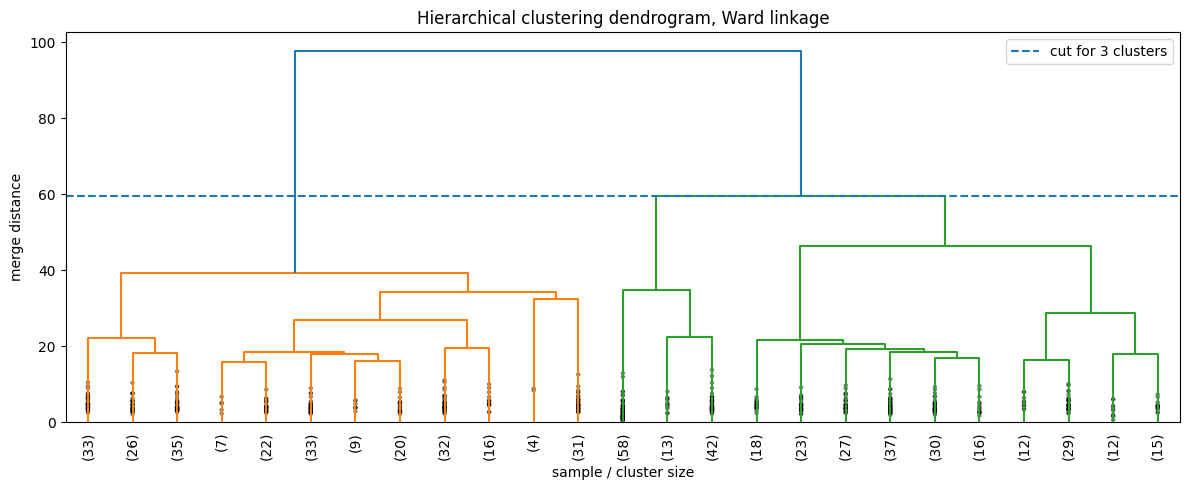

,model,k,silhouette,davies_bouldin,calinski_harabasz,min_cluster_pct
0,Hierarchical,2,0.1692,2.0055,7238.2245,49.3428
1,Hierarchical,3,0.1295,2.2746,5593.2706,21.7518
2,Hierarchical,4,0.1062,2.3973,4368.9826,10.8323
3,Hierarchical,5,0.1008,2.3030,3771.0042,7.8868
4,Hierarchical,6,0.1109,2.0571,3400.2227,1.0238
5,Hierarchical,7,0.1075,2.3312,3122.8302,1.0238
6,Hierarchical,8,0.1054,2.1572,2939.9661,1.0238
7,Hierarchical,9,0.1019,2.2080,2780.8629,1.0238
8,Hierarchical,10,0.1004,2.0689,2662.0851,1.0238


Hierarchical silhouette at K=3: 0.1295
Cluster sizes: {0: 15685, 1: 8543, 2: 6735}


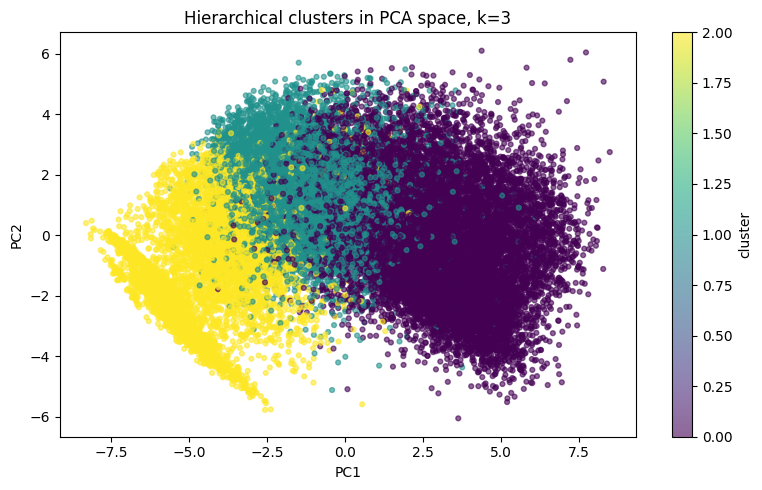

In [13]:
sample_size = min(600, len(X_scaled))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=sample_size, replace=False)
Z = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90, show_contracted=True)
plt.axhline(y=Z[-(K - 1), 2], linestyle="--", label=f"cut for {K} clusters")
plt.title("Hierarchical clustering dendrogram, Ward linkage")
plt.xlabel("sample / cluster size")
plt.ylabel("merge distance")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hierarchical_dendrogram.png", dpi=150)
plt.show()

hier_results = []
for k in K_RANGE:
    agg_model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg_model.fit_predict(X_scaled)
    hier_results.append({
        "model": "Hierarchical",
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "min_cluster_pct": pd.Series(labels).value_counts(normalize=True).min() * 100,
    })

hier_results = pd.DataFrame(hier_results)
display(hier_results.round(4))

agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)
agg_sil = silhouette_score(X_scaled, agg_labels)

print(f"Hierarchical silhouette at K={K}: {agg_sil:.4f}")
print("Cluster sizes:", pd.Series(agg_labels).value_counts().sort_index().to_dict())

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, s=12, alpha=0.6)
plt.title(f"Hierarchical clusters in PCA space, k={K}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hierarchical_pca_clusters.png", dpi=150)
plt.show()

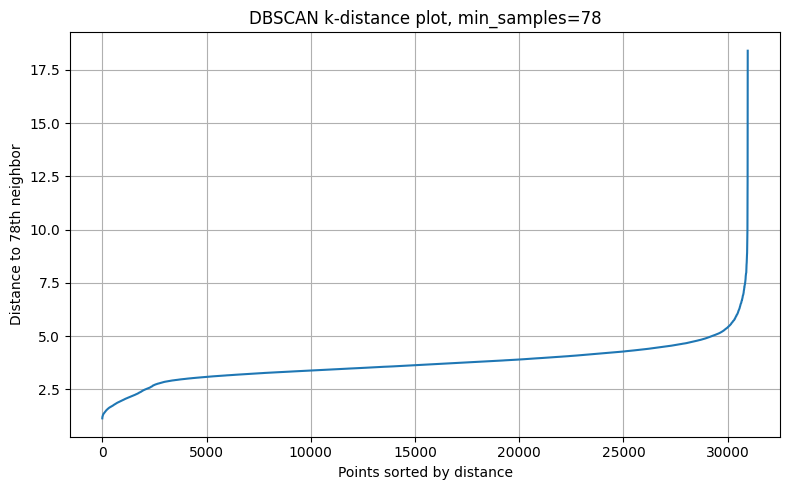

,model,eps,min_samples,n_clusters,noise_rate,silhouette_excluding_noise,davies_bouldin_excluding_noise,calinski_harabasz_excluding_noise
0,DBSCAN,4.010,78,1,0.0513,NaN,NaN,NaN
1,DBSCAN,4.124,78,2,0.0388,0.4013,0.6887,354.4947
2,DBSCAN,4.255,78,2,0.0308,0.4015,0.7140,459.8640
3,DBSCAN,4.418,78,2,0.0251,0.4011,0.7381,523.9275
4,DBSCAN,4.646,78,2,0.0202,0.3977,0.7643,582.7744
5,DBSCAN,4.769,78,2,0.0157,0.3865,0.8676,853.9466
6,DBSCAN,5.063,78,2,0.0119,0.3838,0.9069,1029.6744
7,DBSCAN,5.439,78,2,0.0089,0.3828,0.9221,1073.1907


Chosen DBSCAN eps: 4.255
DBSCAN clusters: 2; noise: 953 (3.1%)
DBSCAN silhouette excluding noise: 0.4015


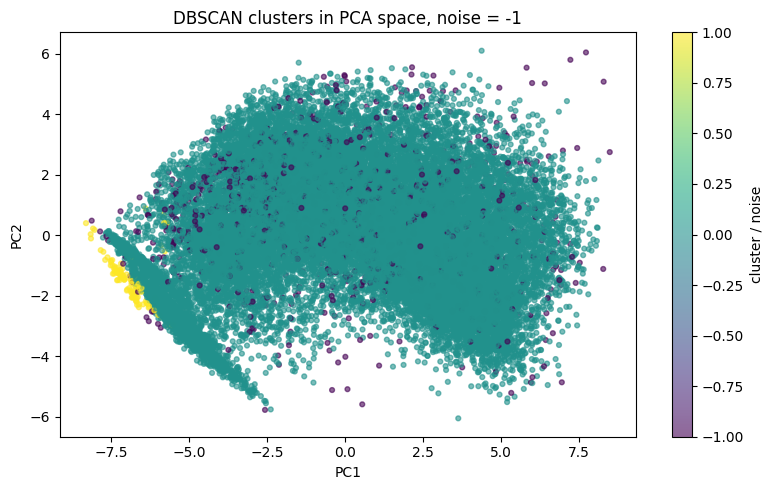

In [14]:
min_samples = max(5, 2 * len(FEATURES))
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f"DBSCAN k-distance plot, min_samples={min_samples}")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th neighbor")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dbscan_k_distance.png", dpi=150)
plt.show()

eps_grid = np.unique(np.round(np.percentile(k_distances, [70, 75, 80, 85, 90, 92, 95, 97]), 3))
dbscan_rows = []

for eps in eps_grid:
    db_model = DBSCAN(eps=float(eps), min_samples=min_samples)
    labels = db_model.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = float((labels == -1).mean())

    mask = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X_scaled[mask], labels[mask])
        dbi = davies_bouldin_score(X_scaled[mask], labels[mask])
        ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
    else:
        sil, dbi, ch = np.nan, np.nan, np.nan

    dbscan_rows.append({
        "model": "DBSCAN",
        "eps": float(eps),
        "min_samples": int(min_samples),
        "n_clusters": int(n_clusters),
        "noise_rate": noise_rate,
        "silhouette_excluding_noise": sil,
        "davies_bouldin_excluding_noise": dbi,
        "calinski_harabasz_excluding_noise": ch,
    })

dbscan_results = pd.DataFrame(dbscan_rows)
display(dbscan_results.round(4))

valid_dbscan = dbscan_results.query("n_clusters >= 2").copy()
if len(valid_dbscan):
    chosen_dbscan_row = valid_dbscan.sort_values(
        ["silhouette_excluding_noise", "noise_rate"],
        ascending=[False, True],
    ).iloc[0]
else:
    chosen_dbscan_row = dbscan_results.iloc[0]

dbscan = DBSCAN(
    eps=float(chosen_dbscan_row["eps"]),
    min_samples=int(chosen_dbscan_row["min_samples"]),
)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
db_mask = db_labels != -1

if n_clusters_db >= 2 and db_mask.sum() > n_clusters_db:
    db_sil = silhouette_score(X_scaled[db_mask], db_labels[db_mask])
else:
    db_sil = np.nan

print("Chosen DBSCAN eps:", float(chosen_dbscan_row["eps"]))
print(f"DBSCAN clusters: {n_clusters_db}; noise: {n_noise} ({n_noise / len(db_labels):.1%})")
print("DBSCAN silhouette excluding noise:", None if pd.isna(db_sil) else round(float(db_sil), 4))

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, s=12, alpha=0.6)
plt.title("DBSCAN clusters in PCA space, noise = -1")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster / noise")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dbscan_pca_clusters.png", dpi=150)
plt.show()

In [15]:
def score_partition(name, labels, allow_noise=False):
    mask = labels != -1 if allow_noise else np.ones(len(labels), dtype=bool)
    label_subset = labels[mask]
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if len(set(label_subset)) < 2:
        return {
            "model": name,
            "n_clusters": n_clusters,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
            "noise_rate": float((labels == -1).mean()) if allow_noise else 0.0,
        }

    return {
        "model": name,
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X_scaled[mask], label_subset),
        "davies_bouldin": davies_bouldin_score(X_scaled[mask], label_subset),
        "calinski_harabasz": calinski_harabasz_score(X_scaled[mask], label_subset),
        "noise_rate": float((labels == -1).mean()) if allow_noise else 0.0,
    }


comparison = pd.DataFrame([
    score_partition("K-Means", km_labels),
    score_partition("Hierarchical", agg_labels),
    score_partition("DBSCAN", db_labels, allow_noise=True),
]).round(4)

ari_km_agg = adjusted_rand_score(km_labels, agg_labels)

comparison.to_csv(REPORT_DIR / "model_comparison.csv", index=False)
kmeans_results.to_csv(REPORT_DIR / "kmeans_k_scan.csv", index=False)
hier_results.to_csv(REPORT_DIR / "hierarchical_k_scan.csv", index=False)
dbscan_results.to_csv(REPORT_DIR / "dbscan_eps_scan.csv", index=False)

display(comparison)
print(f"Adjusted Rand Index, K-Means vs Hierarchical = {ari_km_agg:.4f}")

FINAL_MODEL_NAME = "K-Means"
final_estimator = kmeans
final_labels = km_labels

work = model_df[KEY_COLS + FEATURES + ["final_result"]].copy()
work["cluster"] = final_labels

print("Final model:", FINAL_MODEL_NAME)
display(work["cluster"].value_counts().sort_index().rename("cluster_size"))

,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_rate
0,K-Means,3,0.1590,2.0097,6751.3679,0.0000
1,Hierarchical,3,0.1295,2.2746,5593.2706,0.0000
2,DBSCAN,2,0.4015,0.7140,459.8640,0.0308


Adjusted Rand Index, K-Means vs Hierarchical = 0.5689
Final model: K-Means


cluster
0    12273
1    12187
2     6503
Name: cluster_size, dtype: int64

,check,mean,std,min,max
0,random_seed_pairwise_ari,0.9997,0.0002,0.9995,1.0000
1,bootstrap_ari,0.9957,0.0026,0.9863,0.9982


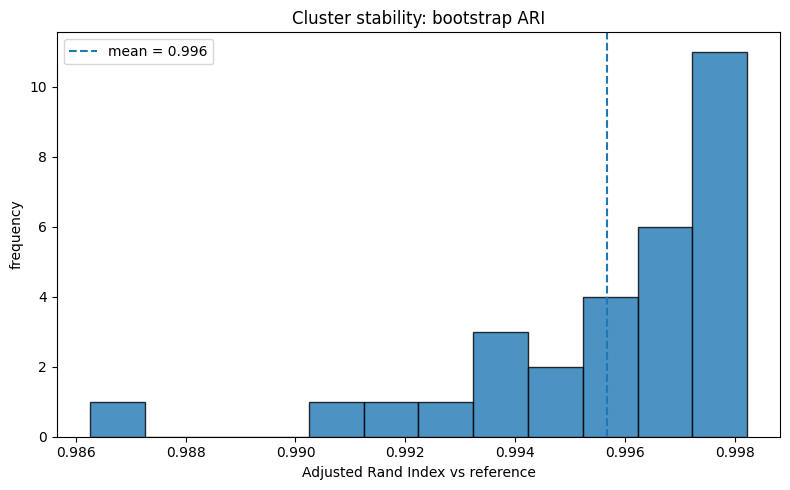

In [16]:
def kmeans_seed_stability(X_arr, k, seeds):
    labels_list = []
    for seed in seeds:
        labels = KMeans(n_clusters=k, random_state=seed, n_init=30).fit_predict(X_arr)
        labels_list.append(labels)

    scores = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            scores.append(adjusted_rand_score(labels_list[i], labels_list[j]))

    return np.array(scores)


def bootstrap_stability(X_arr, k, n_iter=30, sample_frac=0.8, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    ref = KMeans(n_clusters=k, random_state=seed, n_init=30).fit_predict(X_arr)
    aris = []
    n = len(X_arr)

    for _ in range(n_iter):
        idx = rng.choice(n, size=int(sample_frac * n), replace=False)
        labels = KMeans(
            n_clusters=k,
            random_state=int(rng.randint(1_000_000)),
            n_init=30,
        ).fit_predict(X_arr[idx])
        aris.append(adjusted_rand_score(ref[idx], labels))

    return np.array(aris)


seed_aris = kmeans_seed_stability(X_scaled, K, seeds=[1, 2, 3, 4, 5, 42, 100])
boot_aris = bootstrap_stability(X_scaled, K, n_iter=30)

stability_summary = pd.DataFrame([
    {
        "check": "random_seed_pairwise_ari",
        "mean": seed_aris.mean(),
        "std": seed_aris.std(),
        "min": seed_aris.min(),
        "max": seed_aris.max(),
    },
    {
        "check": "bootstrap_ari",
        "mean": boot_aris.mean(),
        "std": boot_aris.std(),
        "min": boot_aris.min(),
        "max": boot_aris.max(),
    },
]).round(4)

stability_summary.to_csv(REPORT_DIR / "cluster_stability_summary.csv", index=False)

display(stability_summary)

plt.figure(figsize=(8, 5))
plt.hist(boot_aris, bins=12, edgecolor="black", alpha=0.8)
plt.axvline(boot_aris.mean(), linestyle="--", label=f"mean = {boot_aris.mean():.3f}")
plt.title("Cluster stability: bootstrap ARI")
plt.xlabel("Adjusted Rand Index vs reference")
plt.ylabel("frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_stability_bootstrap_ari.png", dpi=150)
plt.show()

In [17]:
profile_work = work.merge(profile_df, on=KEY_COLS, how="left", suffixes=("", "_profile"))

numeric_profile_cols = []
for col in FEATURES + [
    "vle_total_clicks",
    "vle_active_days",
    "vle_distinct_sites",
    "assess_n_submitted",
    "assess_mean_score",
    "assess_mean_days_before_deadline",
    "assess_n_late",
    "num_of_prev_attempts",
    "studied_credits",
]:
    if col in profile_work.columns and pd.api.types.is_numeric_dtype(profile_work[col]) and col not in numeric_profile_cols:
        numeric_profile_cols.append(col)

cluster_profile = profile_work.groupby("cluster")[numeric_profile_cols].mean().round(3)
cluster_profile["size"] = profile_work.groupby("cluster").size()
cluster_profile["pct"] = (cluster_profile["size"] / len(profile_work) * 100).round(2)

final_result_by_cluster = pd.crosstab(
    profile_work["cluster"],
    profile_work["final_result"],
    normalize="index",
).round(3)

login_time_by_cluster = (
    pd.crosstab(profile_work["cluster"], profile_work["dominant_login_time"], normalize="index").round(3)
    if "dominant_login_time" in profile_work.columns
    else pd.DataFrame()
)

module_by_cluster = pd.crosstab(
    profile_work["cluster"],
    profile_work["code_module"],
    normalize="index",
).round(3)

cluster_profile.to_csv(REPORT_DIR / "cluster_profile_numeric.csv")
final_result_by_cluster.to_csv(REPORT_DIR / "cluster_final_result_distribution.csv")
login_time_by_cluster.to_csv(REPORT_DIR / "cluster_login_time_distribution.csv")
module_by_cluster.to_csv(REPORT_DIR / "cluster_module_distribution.csv")

display(cluster_profile)
display(final_result_by_cluster)
display(login_time_by_cluster)
display(module_by_cluster)

,login_weekly,video_completion_rate,forum_posts_count,days_to_first_filled,submission_timeliness_days,never_started,missed_submission,late_submitter,prompt_starter,low_engagement_flag,early_start_score,frequency_score,intensity_score,forum_per_login,procrastination_score,engagement_breadth,registration_delay_days,vle_total_clicks,vle_active_days,vle_distinct_sites,log_vle_total_clicks,clicks_per_active_day,log_clicks_per_active_day,vle_activity_type_diversity,vle_clicks_forumng_ratio,vle_clicks_oucontent_ratio,vle_clicks_quiz_ratio,vle_clicks_homepage_ratio,assess_n_submitted,assess_mean_score,assess_n_banked,assess_mean_days_before_deadline,assess_n_late,assessment_completion_rate,late_assessment_rate,login_time_Afternoon,login_time_Evening,login_time_Morning,login_time_Night,num_of_prev_attempts,studied_credits,size,pct
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.705,0.244,0.146,28.273,1.479,0.185,0.023,0.006,0.355,0.311,0.130,-1.069,-0.909,0.068,0.577,0.835,-65.529,784.348,43.118,51.838,6.161,18.035,2.823,7.968,0.175,0.229,0.168,0.219,4.736,66.049,0.075,7.305,1.680,0.546,0.355,0.344,0.260,0.299,0.098,0.187,78.967,12273,39.64
1,5.546,0.788,3.283,6.846,-1.712,0.017,0.001,0.000,0.782,0.001,0.317,1.574,1.607,0.573,-1.147,3.383,-66.356,2001.738,90.910,91.608,7.229,20.720,2.971,9.217,0.189,0.261,0.175,0.194,8.472,78.094,0.029,14.185,2.107,0.942,0.238,0.366,0.240,0.300,0.095,0.115,74.034,12187,39.36
2,0.296,0.156,0.060,30.298,2.170,0.200,0.975,0.037,0.342,0.445,0.128,-1.221,-1.373,0.030,0.863,0.461,-81.700,35.077,2.784,6.199,1.752,5.691,1.133,2.407,0.056,0.093,0.023,0.191,0.050,1.455,0.014,0.275,0.005,0.006,0.003,0.343,0.259,0.301,0.096,0.197,91.286,6503,21.00


final_result,Distinction,Fail,Pass,Withdrawn
cluster,,,,
0,0.004,0.376,0.256,0.365
1,0.218,0.070,0.709,0.004
2,0.000,0.185,0.000,0.814


dominant_login_time,Afternoon,Evening,Morning,Night
cluster,,,,
0,0.344,0.260,0.299,0.098
1,0.366,0.240,0.300,0.095
2,0.343,0.259,0.301,0.096


code_module,AAA,BBB,CCC,DDD,EEE,FFF,GGG
cluster,,,,,,,
0,0.025,0.239,0.158,0.214,0.081,0.210,0.072
1,0.031,0.231,0.105,0.176,0.109,0.254,0.095
2,0.006,0.284,0.149,0.202,0.084,0.208,0.066


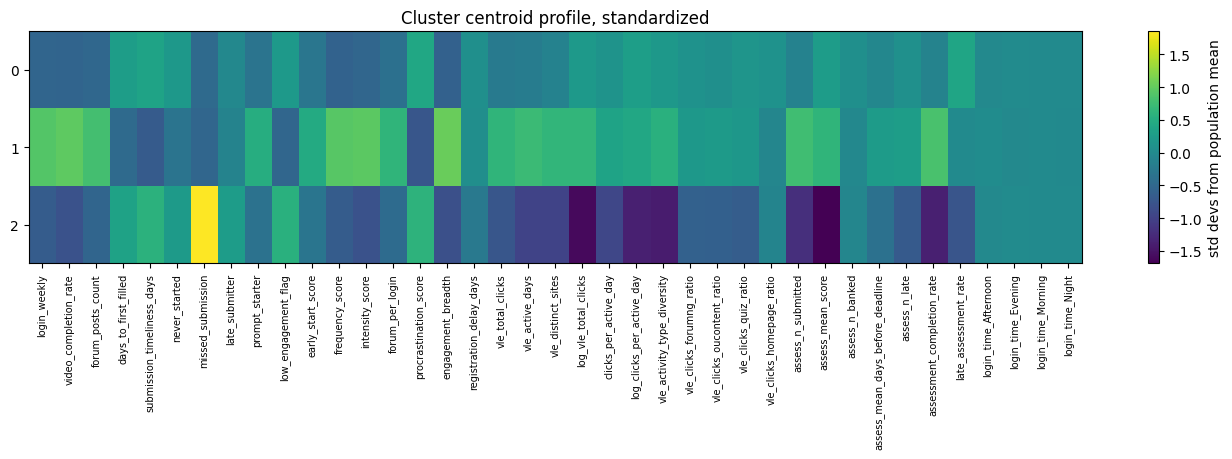

,login_weekly,video_completion_rate,forum_posts_count,days_to_first_filled,submission_timeliness_days,never_started,missed_submission,late_submitter,prompt_starter,low_engagement_flag,early_start_score,frequency_score,intensity_score,forum_per_login,procrastination_score,engagement_breadth,registration_delay_days,vle_total_clicks,vle_active_days,vle_distinct_sites,log_vle_total_clicks,clicks_per_active_day,log_clicks_per_active_day,vle_activity_type_diversity,vle_clicks_forumng_ratio,vle_clicks_oucontent_ratio,vle_clicks_quiz_ratio,vle_clicks_homepage_ratio,assess_n_submitted,assess_mean_score,assess_n_banked,assess_mean_days_before_deadline,assess_n_late,assessment_completion_rate,late_assessment_rate,login_time_Afternoon,login_time_Evening,login_time_Morning,login_time_Night
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.54,-0.55,-0.51,0.28,0.36,0.19,-0.47,-0.04,-0.33,0.23,-0.30,-0.57,-0.52,-0.38,0.41,-0.59,0.08,-0.22,-0.20,-0.12,0.21,0.13,0.29,0.20,0.11,0.08,0.15,0.11,-0.11,0.27,0.07,-0.05,0.08,-0.10,0.39,-0.02,0.02,-0.0,0.01
1,0.90,0.97,0.80,-0.47,-0.68,-0.32,-0.52,-0.10,0.52,-0.52,0.47,0.93,0.95,0.63,-0.74,1.04,0.06,0.63,0.72,0.64,0.65,0.37,0.44,0.56,0.20,0.24,0.19,-0.06,0.76,0.63,-0.04,0.25,0.28,0.84,0.01,0.03,-0.03,-0.0,-0.01
2,-0.66,-0.79,-0.54,0.35,0.59,0.24,1.85,0.27,-0.36,0.55,-0.31,-0.66,-0.80,-0.46,0.61,-0.83,-0.25,-0.75,-0.98,-0.98,-1.60,-0.94,-1.37,-1.42,-0.59,-0.60,-0.64,-0.09,-1.21,-1.69,-0.07,-0.37,-0.69,-1.38,-0.75,-0.02,0.02,0.0,-0.00


In [18]:
centroid_raw = profile_work.groupby("cluster")[FEATURES].mean()
centroid_z = (centroid_raw - profile_work[FEATURES].mean()) / profile_work[FEATURES].std()
centroid_z = centroid_z.replace([np.inf, -np.inf], 0).fillna(0)

plt.figure(figsize=(max(12, len(FEATURES) * 0.35), 0.9 * K + 2))
plt.imshow(centroid_z, aspect="auto")
plt.colorbar(label="std devs from population mean")
plt.xticks(range(len(centroid_z.columns)), centroid_z.columns, rotation=90, fontsize=7)
plt.yticks(range(len(centroid_z.index)), centroid_z.index)
plt.title("Cluster centroid profile, standardized")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_centroid_heatmap.png", dpi=150)
plt.show()

display(centroid_z.round(2))

,cluster,persona,size,pct,risk_level,description,recommendation
0,0,Steady Moderate,12273,39.64,Medium,Average learner profile with stable but not st...,Use light encouragement and next-best-content ...
1,1,Consistent Achiever,12187,39.36,Low,High engagement and strong performance with re...,"Offer enrichment content, optional advanced ta..."
2,2,At-Risk Disengaged,6503,21.00,High,Very low engagement or never-started behavior;...,"Tutor outreach, onboarding support, simplified..."


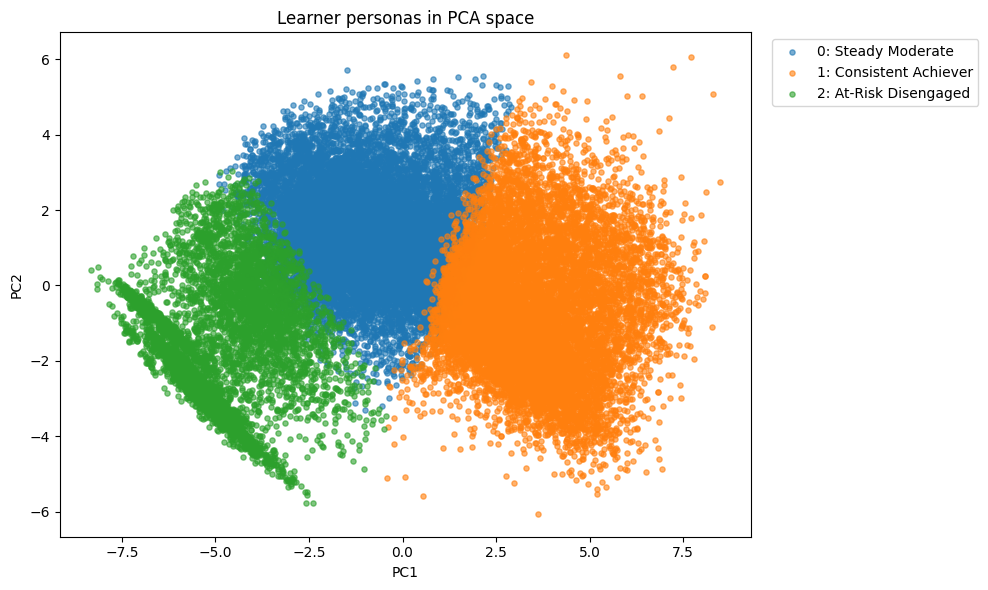

In [19]:
def z_mean(row, names):
    vals = [row[c] for c in names if c in row.index]
    return float(np.mean(vals)) if vals else 0.0


def persona_from_centroid(row):
    engagement = z_mean(row, [
        "login_weekly",
        "video_completion_rate",
        "forum_posts_count",
        "log_vle_total_clicks",
        "log_vle_active_days",
        "vle_activity_type_diversity",
    ])
    performance = z_mean(row, [
        "assess_mean_score",
        "assessment_completion_rate",
        "assignment_timeliness_score",
    ])
    delay = z_mean(row, [
        "days_to_first_filled",
        "procrastination_score",
        "submission_timeliness_days",
        "late_assessment_rate",
    ])
    risk = z_mean(row, [
        "never_started",
        "missed_submission",
        "low_engagement_flag",
    ])

    if risk > 0.6 and engagement < -0.2:
        return (
            "At-Risk Disengaged",
            "Very low engagement or never-started behavior; highest priority for proactive support.",
            "High",
            "Tutor outreach, onboarding support, simplified first tasks, and early-warning follow-up.",
        )

    if engagement > 0.45 and performance > 0.25 and delay < 0.4:
        return (
            "Consistent Achiever",
            "High engagement and strong performance with relatively healthy pacing.",
            "Low",
            "Offer enrichment content, optional advanced tasks, and peer-mentor opportunities.",
        )

    if engagement > 0.35 and performance < -0.25:
        return (
            "Active Struggler",
            "Learner is active but performance does not match effort.",
            "Medium-High",
            "Recommend remedial content, targeted quiz review, and instructor feedback.",
        )

    if delay > 0.45 and engagement > -0.25:
        return (
            "Last-Minute Crammer",
            "Engagement exists but timing is late or bursty around deadlines.",
            "Medium",
            "Use milestone reminders, calendar nudges, and smaller weekly pacing goals.",
        )

    if engagement < -0.35:
        return (
            "Passive Low-Engagement",
            "Below-average activity without enough evidence of steady learning behavior.",
            "Medium-High",
            "Send re-engagement messages, low-friction quick-win activities, and check-in prompts.",
        )

    return (
        "Steady Moderate",
        "Average learner profile with stable but not standout activity.",
        "Medium",
        "Use light encouragement and next-best-content recommendations.",
    )


persona_rows = []
used_names = {}

for cluster_id in sorted(centroid_z.index):
    persona, description, risk_level, recommendation = persona_from_centroid(centroid_z.loc[cluster_id])
    if persona in used_names:
        used_names[persona] += 1
        persona = f"{persona} {used_names[persona]}"
    else:
        used_names[persona] = 1

    persona_rows.append({
        "cluster": int(cluster_id),
        "persona": persona,
        "size": int(cluster_profile.loc[cluster_id, "size"]),
        "pct": float(cluster_profile.loc[cluster_id, "pct"]),
        "risk_level": risk_level,
        "description": description,
        "recommendation": recommendation,
    })

persona_summary = pd.DataFrame(persona_rows)
persona_map = dict(zip(persona_summary["cluster"], persona_summary["persona"]))

profile_work["persona"] = profile_work["cluster"].map(persona_map)
work["persona"] = work["cluster"].map(persona_map)

persona_summary.to_csv(REPORT_DIR / "persona_summary.csv", index=False)

display(persona_summary)

plt.figure(figsize=(10, 6))
for cluster_id in sorted(work["cluster"].unique()):
    mask = work["cluster"] == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=14,
        alpha=0.6,
        label=f"{cluster_id}: {persona_map[cluster_id]}",
    )

plt.title("Learner personas in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "persona_pca_scatter.png", dpi=150)
plt.show()

In [20]:
feature_list_path = OUTPUT_DIR / "selected_features.json"
metadata_json_path = OUTPUT_DIR / "model_metadata.json"
learner_segments_path = OUTPUT_DIR / "learners_with_segments.csv"

joblib.dump(scaler, OUTPUT_DIR / "scaler.joblib")
joblib.dump(final_estimator, OUTPUT_DIR / "kmeans_model.joblib")
joblib.dump(outlier_scaler, OUTPUT_DIR / "outlier_scaler.joblib")
joblib.dump(outlier_model, OUTPUT_DIR / "outlier_model.joblib")

with open(feature_list_path, "w") as f:
    json.dump(FEATURES, f, indent=2)

metadata = {
    "model": FINAL_MODEL_NAME,
    "feature_set": final_feature_set_name,
    "k": int(K),
    "features": FEATURES,
    "n_model_rows": int(len(work)),
    "silhouette": float(km_sil),
    "hierarchical_silhouette_at_k": float(agg_sil),
    "dbscan_silhouette_excluding_noise": None if pd.isna(db_sil) else float(db_sil),
    "ari_kmeans_hierarchical": float(ari_km_agg),
    "stability_seed_mean_ari": float(seed_aris.mean()),
    "stability_bootstrap_mean_ari": float(boot_aris.mean()),
    "persona_map": {str(k): v for k, v in persona_map.items()},
}

with open(metadata_json_path, "w") as f:
    json.dump(metadata, f, indent=2)

profile_work.to_csv(learner_segments_path, index=False)

module4_report = {
    "rows_original": int(before_rows),
    "rows_after_key_dedup": int(after_rows),
    "rows_for_model": int(len(model_df)),
    "candidate_features": candidate_features,
    "selected_features": selected_features,
    "dropped_low_variance": dropped_low_variance,
    "dropped_high_corr": dropped_high_corr,
    "remove_outliers_for_model": bool(REMOVE_OUTLIERS_FOR_MODEL),
    "outlier_contamination": float(OUTLIER_CONTAMINATION),
}

with open(REPORT_DIR / "module4_feature_engineering_summary.json", "w") as f:
    json.dump(module4_report, f, indent=2)

print("Saved artifacts:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p)

print("\nSaved reports:")
for p in sorted(REPORT_DIR.iterdir()):
    print(" -", p)

print("\nSaved figures:")
for p in sorted(FIGURE_DIR.iterdir()):
    print(" -", p)

Saved artifacts:
 - artifacts/clustering_features.csv
 - artifacts/engineered_features_raw.csv
 - artifacts/kmeans_model.joblib
 - artifacts/learners_with_segments.csv
 - artifacts/model_metadata.json
 - artifacts/outlier_model.joblib
 - artifacts/outlier_scaler.joblib
 - artifacts/scaler.joblib
 - artifacts/selected_features.json
 - artifacts/student_metadata.csv

Saved reports:
 - reports/cluster_final_result_distribution.csv
 - reports/cluster_login_time_distribution.csv
 - reports/cluster_module_distribution.csv
 - reports/cluster_profile_numeric.csv
 - reports/cluster_stability_summary.csv
 - reports/dbscan_eps_scan.csv
 - reports/feature_selection_report.csv
 - reports/hierarchical_k_scan.csv
 - reports/kmeans_k_scan.csv
 - reports/model_comparison.csv
 - reports/module4_feature_engineering_summary.json
 - reports/outlier_audit_by_final_result.csv
 - reports/persona_summary.csv

Saved figures:
 - figures/candidate_feature_correlation.png
 - figures/cluster_centroid_heatmap.png
 -

In [21]:
loaded_scaler = joblib.load(OUTPUT_DIR / "scaler.joblib")
loaded_model = joblib.load(OUTPUT_DIR / "kmeans_model.joblib")

new_learner = model_df[FEATURES].median().to_frame().T
for col, value in {
    "login_weekly": 6,
    "video_completion_rate": 0.85,
    "forum_posts_count": 3,
    "days_to_first_filled": 2,
    "submission_timeliness_days": -1,
    "never_started": 0,
    "missed_submission": 0,
    "assessment_completion_rate": 0.9,
    "assess_mean_score": 78,
}.items():
    if col in new_learner.columns:
        new_learner[col] = value

pred_cluster = int(loaded_model.predict(loaded_scaler.transform(new_learner[FEATURES]))[0])
pred_persona = persona_map[pred_cluster]

print("New learner assigned to cluster:", pred_cluster)
print("Persona:", pred_persona)
display(new_learner[FEATURES])

New learner assigned to cluster: 0
Persona: Steady Moderate


,login_weekly,video_completion_rate,forum_posts_count,days_to_first_filled,submission_timeliness_days,never_started,missed_submission,late_submitter,prompt_starter,low_engagement_flag,early_start_score,frequency_score,intensity_score,forum_per_login,procrastination_score,engagement_breadth,registration_delay_days,vle_total_clicks,vle_active_days,vle_distinct_sites,log_vle_total_clicks,clicks_per_active_day,log_clicks_per_active_day,vle_activity_type_diversity,vle_clicks_forumng_ratio,vle_clicks_oucontent_ratio,vle_clicks_quiz_ratio,vle_clicks_homepage_ratio,assess_n_submitted,assess_mean_score,assess_n_banked,assess_mean_days_before_deadline,assess_n_late,assessment_completion_rate,late_assessment_rate,login_time_Afternoon,login_time_Evening,login_time_Morning,login_time_Night
0,6,0.85,3,2,-1,0,0,0.0,1.0,0.0,0.111111,-1.042985,-0.166119,0.0,-0.239355,1.0,-57.0,583.0,39.0,45.0,6.369901,14.789474,2.759343,8.0,0.103801,0.17094,0.069168,0.189811,5.0,78,0.0,0.0,0.0,0.9,0.0,0.0,0.0,0.0,0.0
